# Resampling signals on the 2-sphere

This notebook demonstrates how to resample spherical signals between different
grid resolutions and types using `ResampleS2`. The module performs separable
interpolation along latitudes and longitudes, with proper handling of periodicity
and pole values.

Two interpolation modes are available:

- **bilinear** (default): standard linear interpolation in value space,
  $f(t) = (1-t)\,f_0 + t\,f_1$
- **bilinear-spherical**: spherical linear interpolation (slerp), which
  interpolates along great-circle arcs — better suited for angular quantities
  like wind directions or phases

## Setup

In [18]:
import math

from torch_harmonics import ResampleS2
from torch_harmonics.quadrature import precompute_latitudes
from torch_harmonics.utils import load_mola_elevation

import matplotlib.pyplot as plt
from torch_harmonics.plotting import plot_sphere

## Test data

We use the MOLA Mars topography as test data and set up an equiangular grid:

In [19]:
nlat = 257
nlon = 2*(nlat-1)
grid = "equiangular"

xq, wq = precompute_latitudes(nlat, grid=grid)

In [20]:
data = load_mola_elevation(nlat, nlon)

Let us visualize the original data:

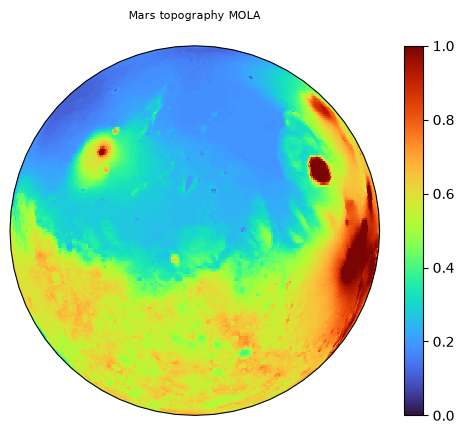

In [21]:
plot_sphere(data, projection="orthographic", cmap="turbo", colorbar=True, title="Mars topography MOLA")
plt.show()

## Grid-to-grid transfer

`ResampleS2` can transfer data between different grid types at the same
resolution. Here we resample from equiangular to equiangular as a sanity check:

In [22]:
grid_up = "equiangular"
grid_down = "legendre-gauss"

input_resample = ResampleS2(nlat, nlon, nlat, nlon, grid_in="equiangular", grid_out=grid_up)

data_res = input_resample(data)

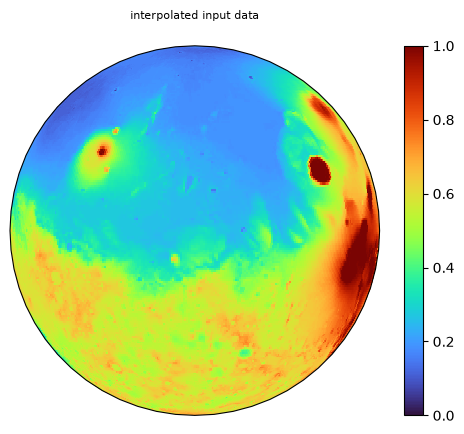

In [23]:
plot_sphere(data_res, projection="orthographic", cmap="turbo", colorbar=True, title="interpolated input data")

## Down- and upsampling

We define downsampling and upsampling layers with a scale factor of 4.
The downsampled grid uses Legendre–Gauss nodes, which is a common choice
for spectral methods:

In [24]:
scale_factor = 4

nlat_down = math.ceil(nlat / scale_factor)
nlon_down = math.ceil(nlon / scale_factor)

downsample = ResampleS2(nlat, nlon, nlat_down, nlon_down, grid_in=grid_up)
upsample = ResampleS2(nlat_down, nlon_down, nlat, nlon, grid_in=grid_down)

In [25]:
data_down = downsample(data)
data_up = upsample(data_down)

The four panels show the original, downsampled, upsampled, and residual fields.
The residual reveals information lost during the downsampling step:

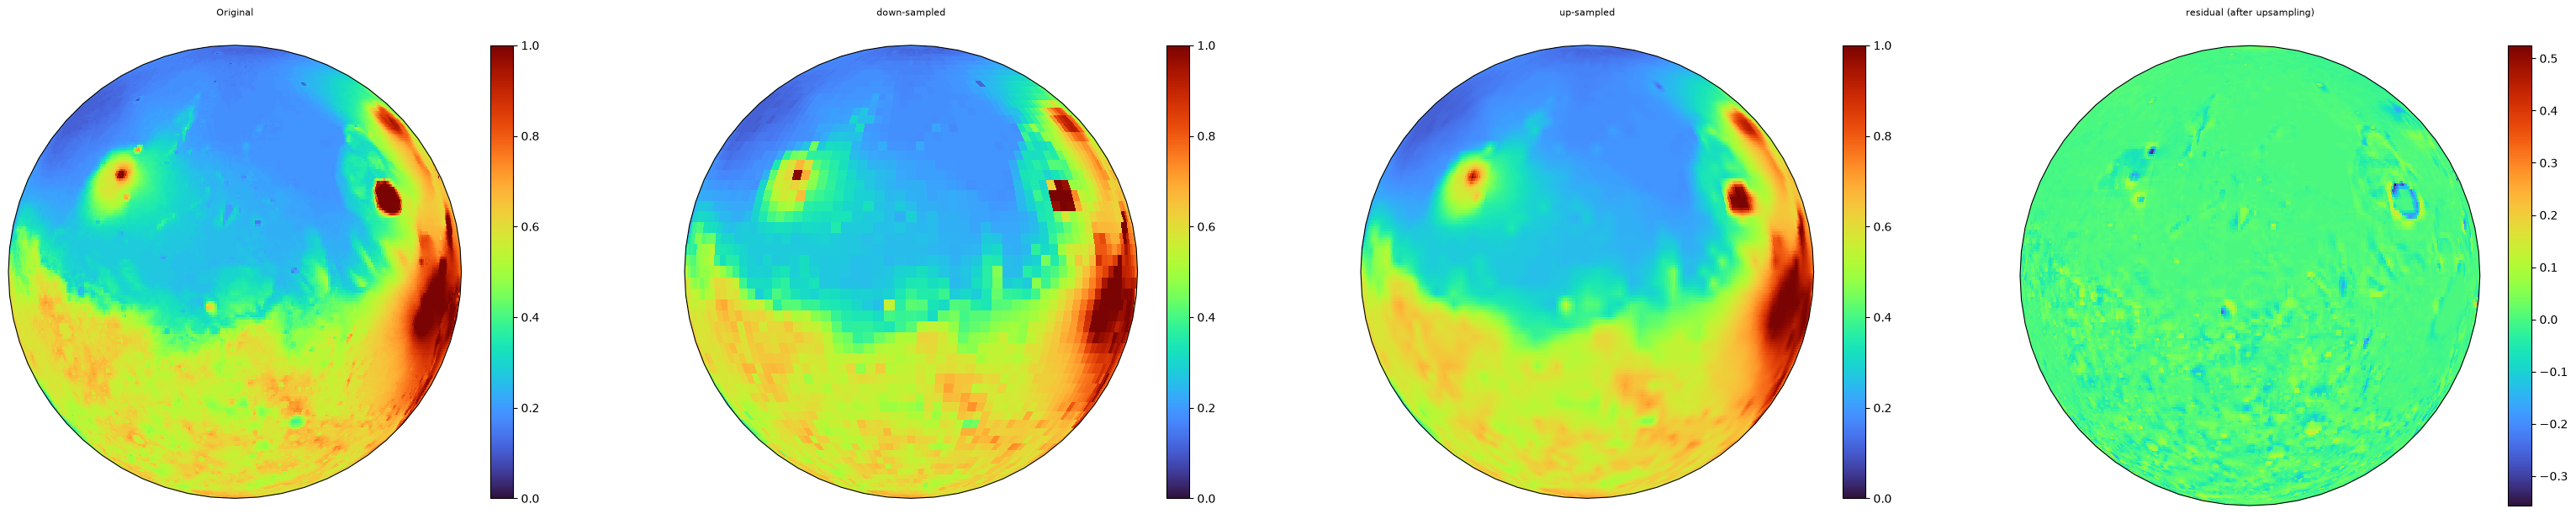

In [26]:
fig = plt.figure(layout='constrained', figsize=(32, 6))
subfigs = fig.subfigures(1, 4)

# spectral fitting
plot_sphere(data, fig=subfigs[0], projection="orthographic", cmap="turbo", colorbar=True, title="Original")
plot_sphere(data_down, fig=subfigs[1], projection="orthographic", cmap="turbo", colorbar=True, title="down-sampled")
plot_sphere(data_up, fig=subfigs[2], projection="orthographic", cmap="turbo", colorbar=True, title="up-sampled")
plot_sphere((data_up - data), fig=subfigs[3], projection="orthographic", cmap="turbo", colorbar=True, title="residual (after upsampling)")
plt.show()

In [27]:
print((data_up - data).abs().max())

tensor(0.5244)


## Comparison with SHT upsampling

An alternative to interpolation-based upsampling is to go through spectral space:
apply the forward SHT on the coarse grid, then the inverse SHT on the fine grid.
This is spectrally exact for band-limited signals but can produce Gibbs-type
ringing near sharp features:

In [28]:
from torch_harmonics import RealSHT, InverseRealSHT

sht = RealSHT(nlat_down, nlon_down, grid=grid_down)
isht = InverseRealSHT(nlat, nlon, lmax=sht.lmax, mmax=sht.mmax, grid=grid_up)

In [29]:
data_up = upsample(data_down)
data_sht_up = isht(sht(data_down))

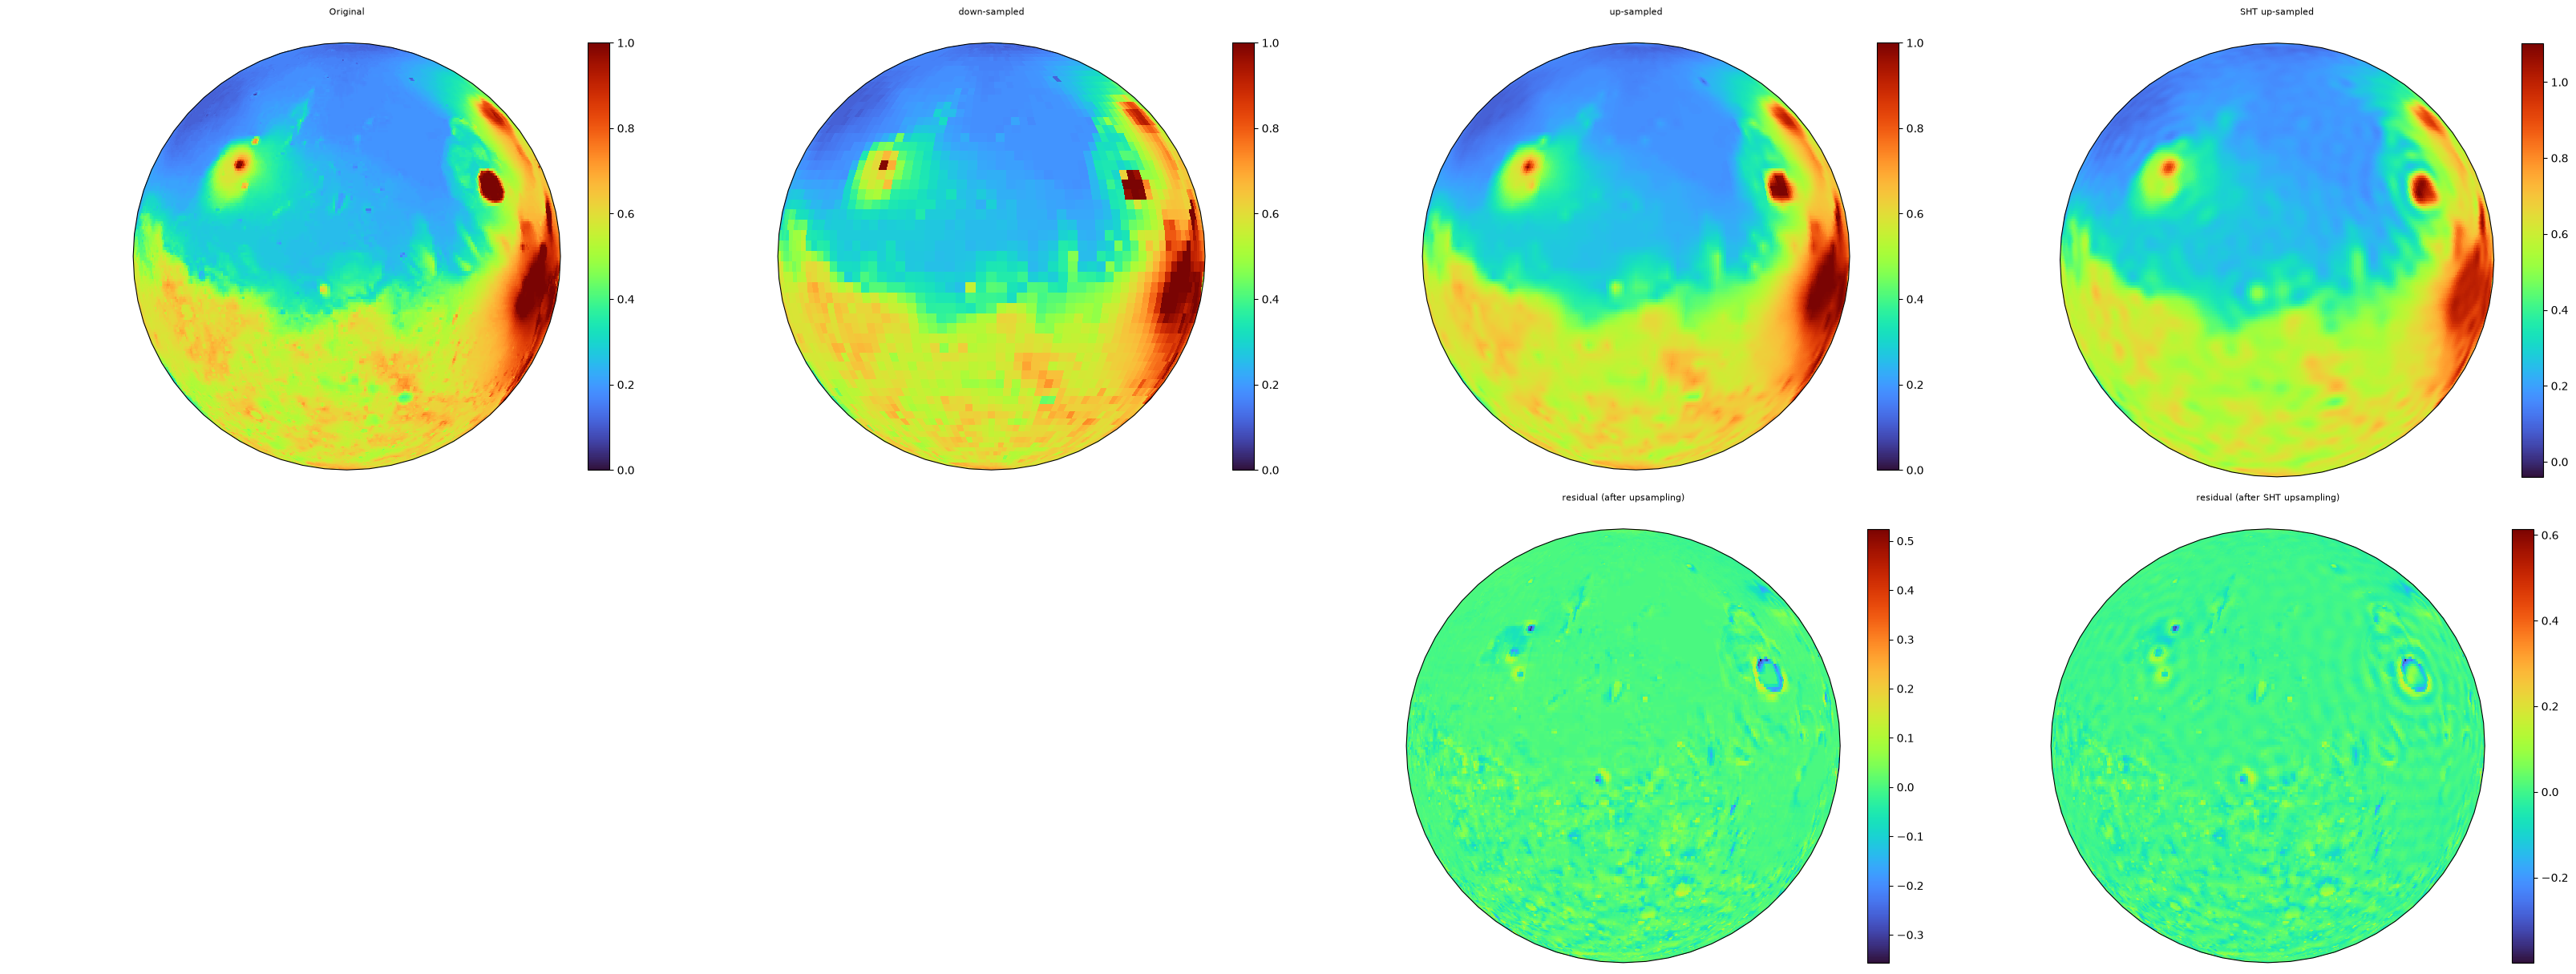

In [30]:
fig = plt.figure(layout='constrained', figsize=(32, 12))
subfigs = fig.subfigures(2, 4)

# spectral fitting
plot_sphere(data, fig=subfigs[0, 0], projection="orthographic", cmap="turbo", colorbar=True, title="Original")
plot_sphere(data_down, fig=subfigs[0, 1], projection="orthographic", cmap="turbo", colorbar=True, title="down-sampled")
plot_sphere(data_up, fig=subfigs[0, 2], projection="orthographic", cmap="turbo", colorbar=True, title="up-sampled")
plot_sphere(data_sht_up, fig=subfigs[0, 3], projection="orthographic", cmap="turbo", colorbar=True, title="SHT up-sampled")
plot_sphere((data_up - data), fig=subfigs[1, 2], projection="orthographic", cmap="turbo", colorbar=True, title="residual (after upsampling)")
plot_sphere((data_sht_up - data), fig=subfigs[1, 3], projection="orthographic", cmap="turbo", colorbar=True, title="residual (after SHT upsampling)")
plt.show()

The SHT upsampling produces visible ringing near sharp topographic features
(craters, ridges), while the interpolation-based approach stays smooth.
The max errors confirm this:

In [31]:
print((data_up - data).abs().max())
print((data_sht_up - data).abs().max())

tensor(0.5244)
tensor(0.6142)


## Bilinear vs. spherical interpolation

`ResampleS2` supports a second mode, `mode="bilinear-spherical"`, which uses
spherical linear interpolation (slerp). Instead of blending linearly in value
space, it treats the difference $\omega = f_1 - f_0$ as an angle and interpolates
along the corresponding arc:

$$
f(t) = \frac{\sin((1-t)\,\omega)}{\sin\omega}\,f_0
     + \frac{\sin(t\,\omega)}{\sin\omega}\,f_1
$$

For small $\omega$ the two modes are identical (slerp falls back to lerp).
The difference grows with $|\omega|$: slerp follows the arc while lerp cuts
the chord.

To isolate this effect we upsample the **same** coarse data with both kernels.
When comparing against the original, the aliasing error from downsampling
dominates and hides the kernel difference. But comparing the two upsampled
results directly reveals where the kernels disagree:

In [32]:
upsample_slerp = ResampleS2(nlat_down, nlon_down, nlat, nlon, grid_in=grid_down, mode="bilinear-spherical")

# upsample the SAME coarse data with both kernels
data_up_bilinear = upsample(data_down)
data_up_slerp = upsample_slerp(data_down)

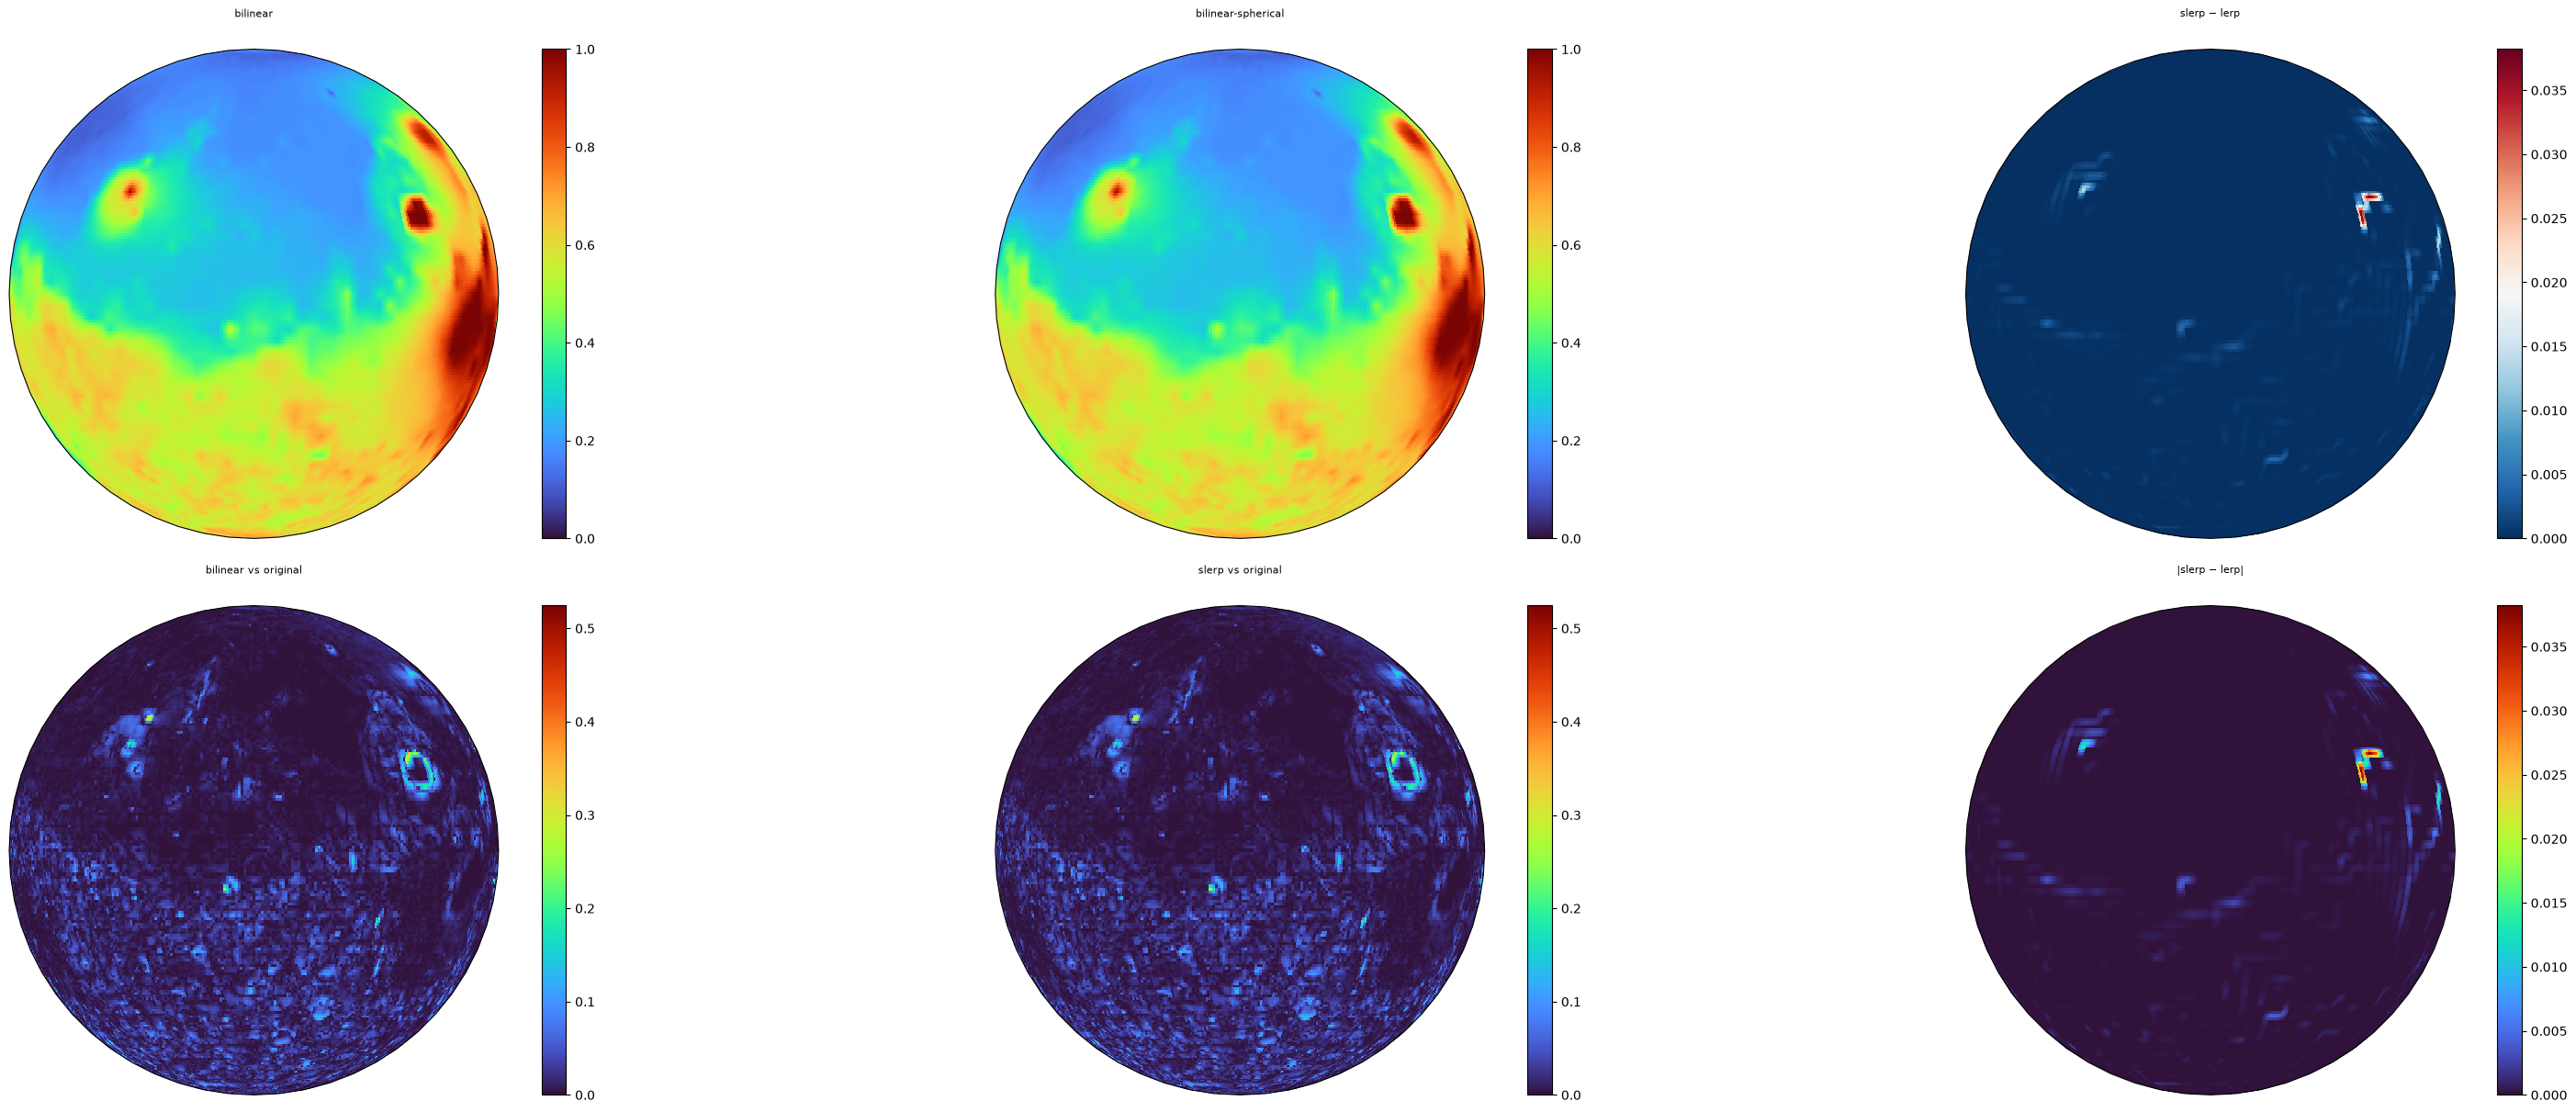

In [33]:
fig = plt.figure(layout='constrained', figsize=(32, 12))
subfigs = fig.subfigures(2, 3)

plot_sphere(data_up_bilinear, fig=subfigs[0, 0], projection="orthographic", cmap="turbo",
            colorbar=True, title="bilinear")
plot_sphere(data_up_slerp, fig=subfigs[0, 1], projection="orthographic", cmap="turbo",
            colorbar=True, title="bilinear-spherical")
plot_sphere((data_up_slerp - data_up_bilinear), fig=subfigs[0, 2], projection="orthographic", cmap="RdBu_r",
            colorbar=True, title="slerp $-$ lerp")

plot_sphere((data_up_bilinear - data).abs(), fig=subfigs[1, 0], projection="orthographic", cmap="turbo",
            colorbar=True, title="bilinear vs original")
plot_sphere((data_up_slerp - data).abs(), fig=subfigs[1, 1], projection="orthographic", cmap="turbo",
            colorbar=True, title="slerp vs original")
plot_sphere((data_up_slerp - data_up_bilinear).abs(), fig=subfigs[1, 2], projection="orthographic", cmap="turbo",
            colorbar=True, title="|slerp $-$ lerp|")
plt.show()

In [34]:
print(f"bilinear vs original:   {(data_up_bilinear - data).abs().max():.4f}")
print(f"slerp vs original:      {(data_up_slerp - data).abs().max():.4f}")
print(f"slerp vs bilinear:      {(data_up_slerp - data_up_bilinear).abs().max():.6f}")

bilinear vs original:   0.5244
slerp vs original:      0.5244
slerp vs bilinear:      0.038213


The kernel difference (`slerp - lerp`) is orders of magnitude smaller than the
aliasing error from downsampling. For smooth scalar fields like topography,
the two modes are effectively interchangeable.

## Conclusion

- **Bilinear vs. bilinear-spherical**: for scalar fields the two interpolation
  kernels produce nearly identical results. The spherical mode is designed for
  fields that represent angles or phases, where value-space averaging is not
  meaningful.
- **Interpolation vs. SHT upsampling**: SHT-based upsampling is spectrally exact
  but prone to Gibbs ringing near discontinuities. Interpolation-based resampling
  trades spectral exactness for smoothness.